# Rep. 4. Checkpoint 1. Payoff diagrams
# Eduardo Veytia Hernández

## Actividad. Payoff Diagrams con datos reales
Esta actividad es necesaria para el reporte integrador 3.

Esta actividad complementa el contenido de la clase "Payoff diagrams".

Usando el código visto en clase y datos reales de SPY con vencimiento al 17 de abril, construirás los payoff diagrams de las cuatro posiciones básicas y analizarás su perfil de riesgo.

## Contexto
Un payoff diagram no es solo una gráfica. es la representación visual de una decisión de inversión. Antes de entrar a cualquier posición con opciones, un trader construye este diagrama para entender exactamente cuánto puede ganar, cuánto puede perder, y en qué condiciones de mercado.



## Instrucciones
Obtén dinámicamente los precios mid del call y put con strike K = 680 y vencimiento 2026-04-17:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")

S0=653.18  K=680  C=3.4100  P=28.4350


Con esos valores, genera:

### 1. El plot 2×2 de las cuatro posiciones básicas con P&L neto

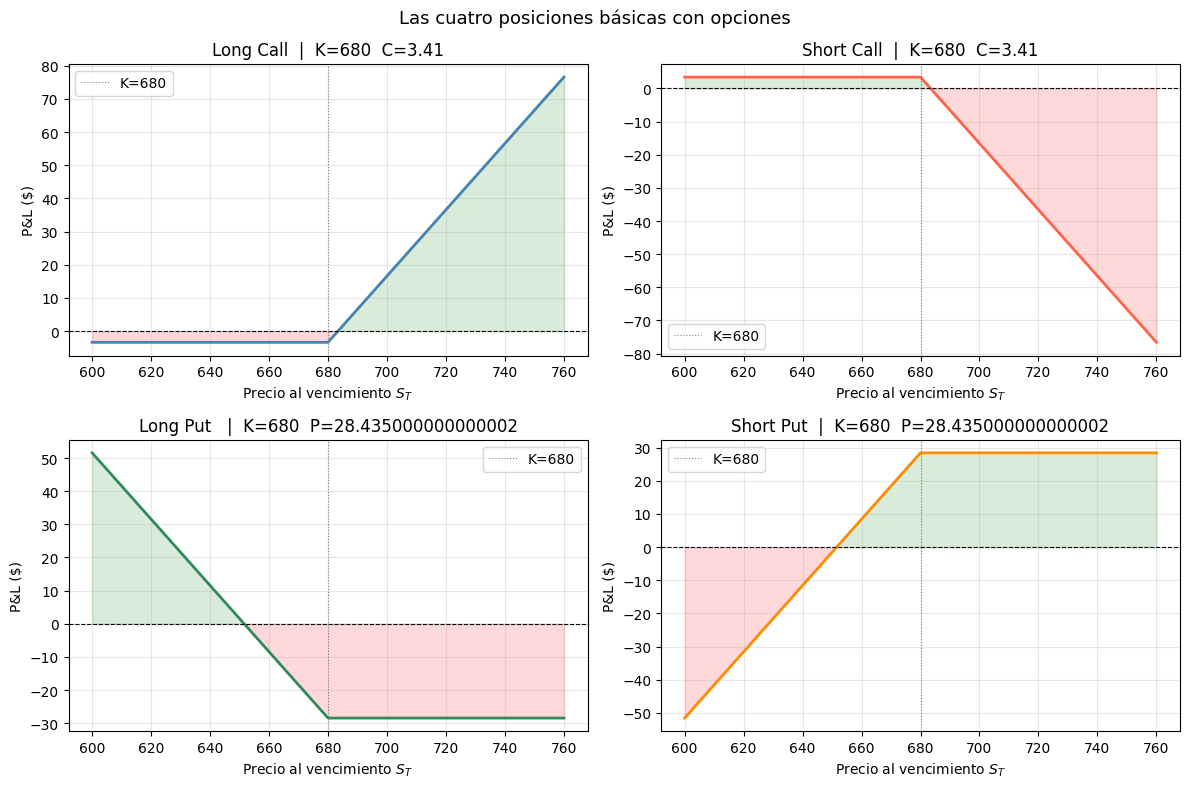

In [3]:
S_range = np.linspace(600, 760, 500)# rango de precios al vencimiento

# --- Payoffs brutos ---
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# --- P&L neto ---
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Las cuatro posiciones básicas con opciones', fontsize=13)
plt.tight_layout()
plt.show()


### 2. La comparación de payoff bruto vs. P&L neto para el call y el put por separado

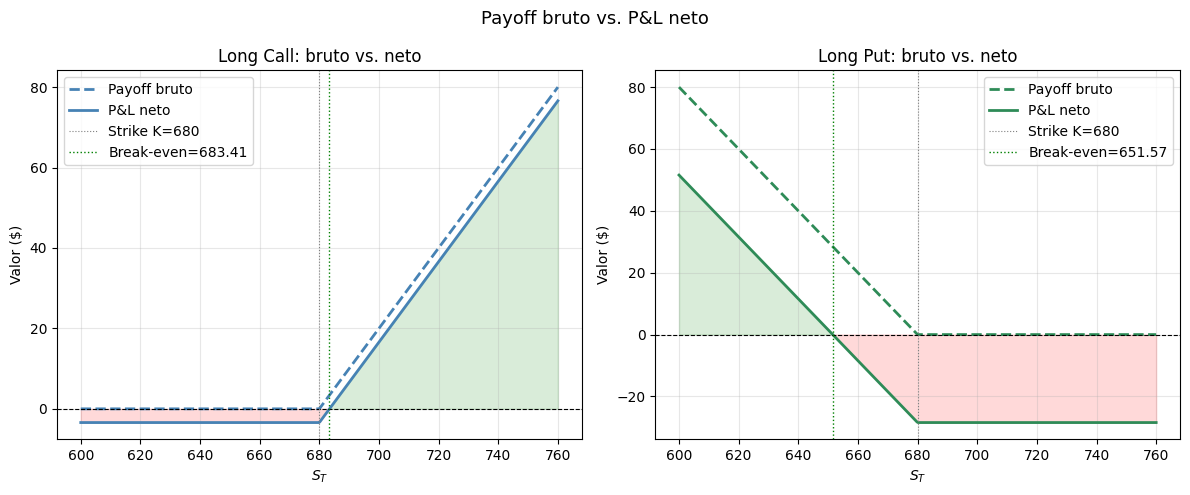

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Long call: comparación bruto vs neto
axes[0].plot(S_range, call_long_bruto, color='steelblue',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[0].plot(S_range, pnl_call_long,   color='steelblue',
             linewidth=2, label='P&L neto')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].axvline(K,     color='gray', linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[0].axvline(K + C, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K+C:.2f}')
axes[0].fill_between(S_range, pnl_call_long, 0,
                     where=(pnl_call_long > 0), alpha=0.15, color='green')
axes[0].fill_between(S_range, pnl_call_long, 0,
                     where=(pnl_call_long < 0), alpha=0.15, color='red')
axes[0].set_title('Long Call: bruto vs. neto')
axes[0].set_xlabel('$S_T$')
axes[0].set_ylabel('Valor ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Long put: comparación bruto vs neto
axes[1].plot(S_range, put_long_bruto, color='seagreen',
             linewidth=2, linestyle='--', label='Payoff bruto')
axes[1].plot(S_range, pnl_put_long,   color='seagreen',
             linewidth=2, label='P&L neto')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(K,     color='gray',  linewidth=0.8,
                linestyle=':', label=f'Strike K={K}')
axes[1].axvline(K - P, color='green', linewidth=1.0,
                linestyle=':', label=f'Break-even={K-P:.2f}')
axes[1].fill_between(S_range, pnl_put_long, 0,
                     where=(pnl_put_long > 0), alpha=0.15, color='green')
axes[1].fill_between(S_range, pnl_put_long, 0,
                     where=(pnl_put_long < 0), alpha=0.15, color='red')
axes[1].set_title('Long Put: bruto vs. neto')
axes[1].set_xlabel('$S_T$')
axes[1].set_ylabel('Valor ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Payoff bruto vs. P&L neto', fontsize=13)
plt.tight_layout()
plt.show()

### 3. Una tabla con los break-evens de las cuatro posiciones

In [5]:
# Definición de los Break-evens y métricas de riesgo
data = {
    'Posición': ['Long Call', 'Short Call', 'Long Put', 'Short Put'],
    'Strike (K)': [K, K, K, K],
    'Prima (C o P)': [C, C, P, P],
    'Break-even': [K + C, K + C, K - P, K - P],
    'Máx. Pérdida': [-C, 'Ilimitada*', -P, 'Limitada (K-P)*'],
    'Máx. Ganancia': ['Ilimitada', C, 'Limitada (K-P)', P]
}

df_resumen = pd.DataFrame(data)

# Formatear para que se vea profesional
pd.options.display.float_format = '{:,.2f}'.format
print("--- Resumen de Puntos Críticos del Portafolio ---")
print(df_resumen.to_string(index=False))

--- Resumen de Puntos Críticos del Portafolio ---
  Posición  Strike (K)  Prima (C o P)  Break-even    Máx. Pérdida  Máx. Ganancia
 Long Call         680           3.41      683.41           -3.41      Ilimitada
Short Call         680           3.41      683.41      Ilimitada*           3.41
  Long Put         680          28.44      651.57          -28.44 Limitada (K-P)
 Short Put         680          28.44      651.57 Limitada (K-P)*          28.44


## Preguntas
### Responde dentro del notebook como celdas de texto (Markdown):

### 1. Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso? 

El Long Put 651.57. Implica que es la posición con mayor probabilidad de éxito.

### 2. Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?

Long Call / Short Call: Pierden/Ganan la prima $C$ 3.41.

Long Put / Short Put: Pierden/Ganan la prima $P$ 28.44.

Al ser $S_T = K$, el payoff bruto es cero para todos; el resultado neto es simplemente el costo o ingreso de la prima.


### 3. Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?

El Short Put tiene más riesgo.
En la Long Call la pérdida está topada a la prima 3.41, mientras que en el Short Put la pérdida puede ser de hasta $K - P$ 651.56 si el activo cae a cero.

### 4. ¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?

Elegiría Long Put.
El Long Put ofrece ganancias ilimitadas (hacia abajo) y se beneficia de un aumento en la volatilidad implícita, mientras que el Short Call tiene ganancia limitada y sufre si la volatilidad sube.
